# ResNet50 Transfer Learning for Brain MRI Classification

Purpose: Apply transfer learning using pretrained ResNet50 for binary brain tumor detection, comparing against custom CNN architectures.

Configuration:
- Pretrained on ImageNet, fine-tuned on brain MRI dataset
- Input: 224x224 RGB images
- Normalization: ImageNet mean and std
- Data augmentation: RandomHorizontalFlip, RandomVerticalFlip, RandomRotation(15)
- Early stopping patience: 10 epochs

Outputs:
- resnet50_best.pth - Best model checkpoint (based on validation AUC)
- resnet50_test_predictions.csv - Test predictions with format: label, pred_class, pred_prob

---

## 1. Environment Setup & Imports

In [7]:
# Standard imports
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# PyTorch imports
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

# Metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)
    
# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cpu


## 2. Dataset Preparation & DataLoaders

In [2]:
# Image size
IMG_SIZE = 224  # ResNet standard input

# Data augmentation & preprocessing
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],  # ImageNet mean
                         [0.229, 0.224, 0.225])  # ImageNet std
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Dataset paths (adjusted for resnet/ folder location)
train_dir = "../dataset_processed/train"
val_dir = "../dataset_processed/val"
test_dir = "../dataset_processed/test"

# Create datasets
train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset = datasets.ImageFolder(val_dir, transform=val_test_transform)
test_dataset = datasets.ImageFolder(test_dir, transform=val_test_transform)

# DataLoaders
BATCH_SIZE = 16
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

print(f"Train size: {len(train_dataset)}, Val size: {len(val_dataset)}, Test size: {len(test_dataset)}")

Train size: 2100, Val size: 450, Test size: 450


## 3. ResNet50 Model Definition

In [3]:
# Load pretrained ResNet50
resnet50 = models.resnet50(pretrained=True)

# Fine-tune all layers
for param in resnet50.parameters():
    param.requires_grad = True

# Modify final fully connected layer for binary classification
num_features = resnet50.fc.in_features
resnet50.fc = nn.Linear(num_features, 2)

# Move to device
resnet50 = resnet50.to(device)
print(f"ResNet50 loaded with {sum(p.numel() for p in resnet50.parameters())} parameters")

c:\Users\mohdf\OneDrive - Singapore Institute Of Technology\Capstone\Project\venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\mohdf\OneDrive - Singapore Institute Of Technology\Capstone\Project\venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ResNet50 loaded with 23512130 parameters


## 4. Training Configuration

In [4]:
# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = torch.optim.Adam(resnet50.parameters(), lr=1e-4)

# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)


## 5. Model Training

Starting ResNet50 Training

Epoch 1/25


Validation: 100%|██████████| 29/29 [00:12<00:00,  2.24it/s]


Time: 185.9s | Train Loss: 0.1667 | Train Acc: 0.9376
Val Loss: 0.0408 | Val Acc: 0.9822 | Val AUC: 0.9993
Checkpoint: Best model saved (Val AUC: 0.9993)

Epoch 2/25


Validation: 100%|██████████| 29/29 [00:12<00:00,  2.24it/s]


Time: 185.9s | Train Loss: 0.0601 | Train Acc: 0.9795
Val Loss: 0.0266 | Val Acc: 0.9911 | Val AUC: 0.9999
Checkpoint: Best model saved (Val AUC: 0.9999)

Epoch 3/25


...

Time: 205.1s | Train Loss: 0.0199 | Train Acc: 0.9943
Val Loss: 0.0645 | Val Acc: 0.9800 | Val AUC: 0.9997

Epoch 20/25


Validation: 100%|██████████| 29/29 [00:15<00:00,  1.84it/s]


Time: 192.1s | Train Loss: 0.0126 | Train Acc: 0.9948
Val Loss: 0.0014 | Val Acc: 1.0000 | Val AUC: 1.0000

Epoch 21/25


Validation: 100%|██████████| 29/29 [00:15<00:00,  1.88it/s]


Time: 221.8s | Train Loss: 0.0137 | Train Acc: 0.9962
Val Loss: 0.0085 | Val Acc: 0.9978 | Val AUC: 1.0000

Early stopping triggered at epoch 21

Training Complete
Best Val AUC: 1.0000 | Best Val Loss: 0.0094


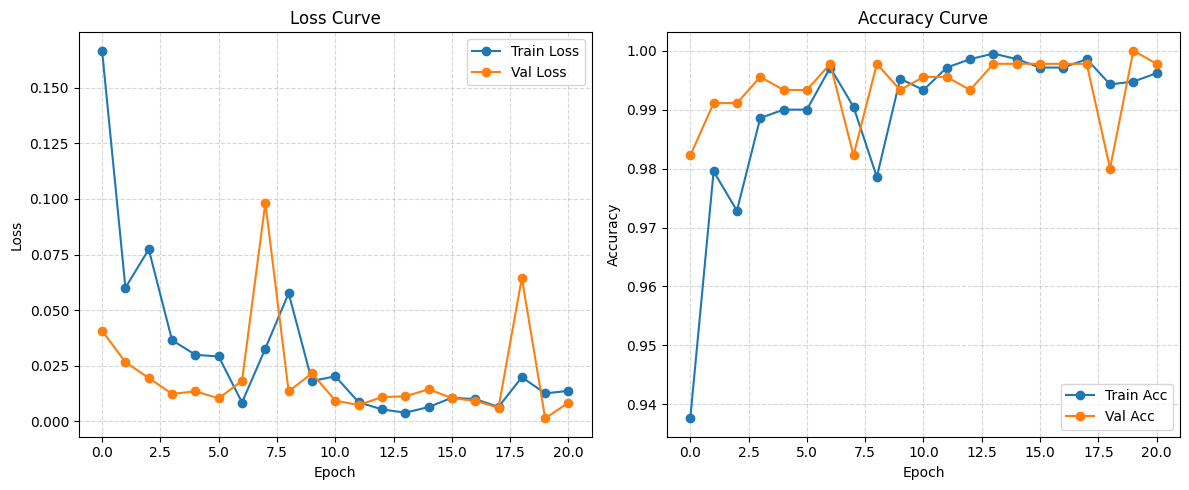

In [5]:
import time

# Training configuration
EPOCHS = 25
best_val_loss = np.inf
best_val_auc = 0.0
early_stop_counter = 0
PATIENCE = 10

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []
val_aucs = []

print("="*60)
print("Starting ResNet50 Training")
print("="*60)

for epoch in range(1, EPOCHS + 1):
    epoch_start = time.time()
    print(f"\nEpoch {epoch}/{EPOCHS}")
    
    # Training phase
    resnet50.train()
    running_loss, correct, total = 0, 0, 0
    
    for images, labels in tqdm(train_loader, desc="Training"):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = resnet50(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
    
    train_loss = running_loss / total
    train_acc = correct / total
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    
    # Validation phase
    resnet50.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    all_labels, all_preds = [], []
    
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Validation"):
            images, labels = images.to(device), labels.to(device)
            outputs = resnet50(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)
            
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(outputs.softmax(dim=1)[:, 1].cpu().numpy())
    
    val_loss /= val_total
    val_acc = val_correct / val_total
    val_auc = roc_auc_score(all_labels, all_preds)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
    val_aucs.append(val_auc)
    
    # Scheduler step
    scheduler.step(val_loss)
    
    # Timing
    epoch_time = time.time() - epoch_start
    
    print(f"Time: {epoch_time:.1f}s | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val AUC: {val_auc:.4f}")
    
    # Save best model based on validation AUC
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_val_loss = val_loss
        torch.save(resnet50.state_dict(), "resnet50_best.pth")
        print(f"Checkpoint: Best model saved (Val AUC: {best_val_auc:.4f})")
        early_stop_counter = 0
    else:
        early_stop_counter += 1
        if early_stop_counter >= PATIENCE:
            print(f"\nEarly stopping triggered at epoch {epoch}")
            break

print("\n" + "="*60)
print("Training Complete")
print(f"Best Val AUC: {best_val_auc:.4f} | Best Val Loss: {best_val_loss:.4f}")
print("="*60)

# Training curves visualization
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss', marker='o')
plt.plot(val_losses, label='Val Loss', marker='o')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.subplot(1,2,2)
plt.plot(train_accuracies, label='Train Acc', marker='o')
plt.plot(val_accuracies, label='Val Acc', marker='o')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 6. Test Set Evaluation

Testing: 100%|██████████| 29/29 [00:13<00:00,  2.15it/s]

Test Set Results
Test Accuracy: 0.9978
Test AUC: 1.0000

Confusion Matrix:
[[224   1]
 [  0 225]]

Classification Report:
              precision    recall  f1-score   support

    No Tumor     1.0000    0.9956    0.9978       225
       Tumor     0.9956    1.0000    0.9978       225

    accuracy                         0.9978       450
   macro avg     0.9978    0.9978    0.9978       450
weighted avg     0.9978    0.9978    0.9978       450


Predictions saved to: resnet50_test_predictions.csv


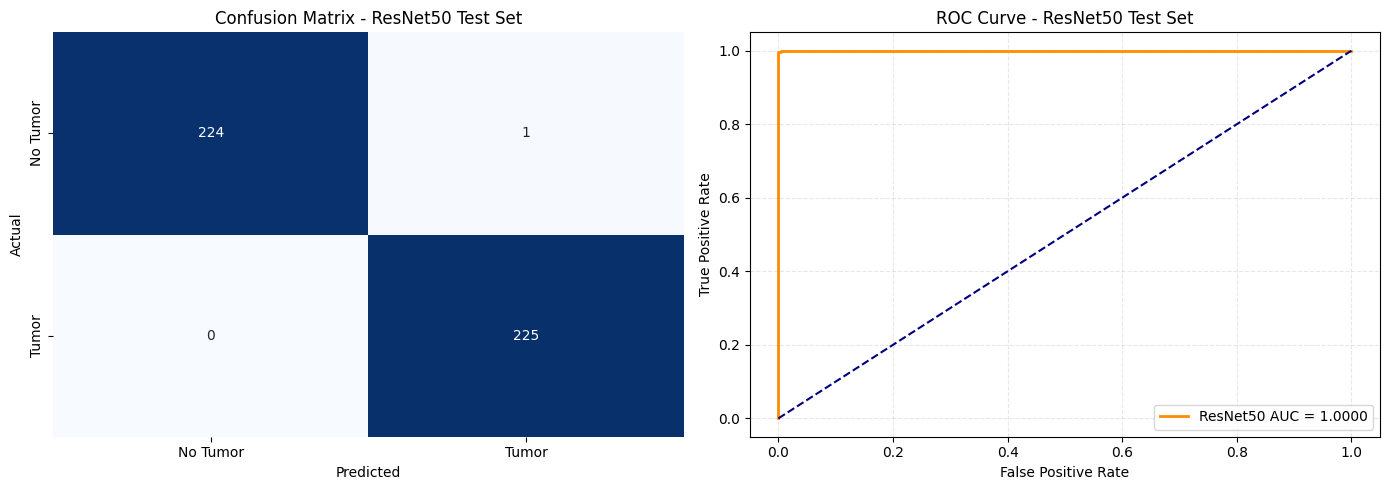

In [8]:
from sklearn.metrics import (
    accuracy_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve, auc
)

# Load best model
resnet50.load_state_dict(torch.load("resnet50_best.pth"))
resnet50.eval()

all_labels, all_preds_class, all_preds_prob = [], [], []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images, labels = images.to(device), labels.to(device)
        outputs = resnet50(images)
        probs = outputs.softmax(dim=1)
        preds = torch.argmax(probs, dim=1)
        
        all_labels.extend(labels.cpu().numpy())
        all_preds_class.extend(preds.cpu().numpy())
        all_preds_prob.extend(probs[:,1].cpu().numpy())

# Compute metrics
test_acc = accuracy_score(all_labels, all_preds_class)
test_auc = roc_auc_score(all_labels, all_preds_prob)
conf_mat = confusion_matrix(all_labels, all_preds_class)
report = classification_report(all_labels, all_preds_class, target_names=['No Tumor', 'Tumor'], digits=4)

print("="*60)
print("Test Set Results")
print("="*60)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test AUC: {test_auc:.4f}")
print("\nConfusion Matrix:")
print(conf_mat)
print("\nClassification Report:")
print(report)
print("="*60)

# Save predictions to resnet folder
predictions_df = pd.DataFrame({
    "label": all_labels,
    "pred_class": all_preds_class,
    "pred_prob": all_preds_prob
})
predictions_df.to_csv("resnet50_test_predictions.csv", index=False)
print("\nPredictions saved to: resnet50_test_predictions.csv")

# Visualization
plt.figure(figsize=(14,5))

# Confusion Matrix
plt.subplot(1,2,1)
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues', cbar=False, 
            xticklabels=['No Tumor', 'Tumor'], yticklabels=['No Tumor', 'Tumor'])
plt.title("Confusion Matrix - ResNet50 Test Set")
plt.xlabel("Predicted")
plt.ylabel("Actual")

# ROC Curve
fpr, tpr, _ = roc_curve(all_labels, all_preds_prob)
roc_auc = auc(fpr, tpr)
plt.subplot(1,2,2)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"ResNet50 AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - ResNet50 Test Set')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

---

## Summary

ResNet50 training complete. All outputs saved to current directory (resnet/):

- **resnet50_best.pth** - Best model checkpoint (selected by validation AUC)
- **resnet50_test_predictions.csv** - Test set predictions with format: label, pred_class, pred_prob

**Key Results:**
- Model leverages ImageNet pretrained weights for feature extraction
- Fine-tuned all layers on brain MRI dataset
- Performance compared against custom CNN architectures

**Next Steps:**
1. Compare ResNet50 vs SimpleCNN performance (test AUC, accuracy, recall)
2. Analyze model efficiency (parameters, inference time, training time)
3. Select final model for deployment and Grad-CAM visualization